## Graph Neural Networks for Urban Analytics 

https://github.com/XiaofengLi1315/Xiaofeng-Li-Advanced-Topics-for-Urban-Analytics.git

## Introduction
With the acceleration of urbanisation, air pollution (particularly PM2.5) has become a key issue threatening public health and the sustainable development of cities. In this assignment, I will apply GNNs to a London PM2.5 dataset to predict an environmental indicator. I will construct a spatial graph, encode geospatial features as node attributes, and use Python to train a graph-based machine learning model.


# 1.Data Exploration 

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = 'AssignmentData-LondonPM25Prediction.geojson'
gdf = gpd.read_file(file_path)

print("Dataset preview:")
print(gdf.head())

print(f"\nCoordinate Reference System (CRS): {gdf.crs}")

Dataset preview:
     oa_code       PM25  k001_PCT  k002_PCT  k003_PCT  k004_PCT  k005_PCT  \
0  E00023264  16.037363  0.655567  0.733280  0.788337  0.809438  0.616867   
1  E00003359  15.571575  0.747233  0.539689  0.833211  0.720010  0.659997   
2  E00023266  16.068834  0.689326  0.758308  0.780265  0.787414  0.633875   
3  E00020264  18.205215  0.749280  0.701306  0.841211  0.773311  0.432955   
4  E00023263  16.128491  0.716956  0.743201  0.823621  0.783315  0.621155   

   k006_PCT  k007_RATIO  k008_PCT  ...  k052_PCT  k053_PCT  k054_PCT  \
0  0.048672    0.497994  0.116873  ...  0.801915  0.574316  0.565354   
1  0.155885    0.389216  0.387319  ...  0.731722  0.346726  0.750254   
2  0.151961    0.542225  0.000000  ...  0.789704  0.603182  0.551503   
3  0.000000    0.480711  0.000000  ...  0.712008  0.454649  0.413096   
4  0.073256    0.532274  0.000000  ...  0.752003  0.656612  0.372115   

   k055_PCT  k056_PCT  k057_PCT  k058_PCT  k059_PCT  k060_PCT  \
0  0.693873  0.607090 

Preliminary findings indicate that PM2.5 concentrations across London’s administrative districts exhibit significant spatial clustering, with values ranging between $15.4$ and $16.4 \mu g/m^3$. Given the slight right-skewed distribution of the data and the small standard deviation, the model must possess a high degree of feature-capturing capability to identify specific geographical units with higher pollution levels amidst a relatively uniform background.




PM2.5 Statistical Summary:
count    25053.000000
mean        15.975608
std          0.783971
min         14.283266
25%         15.403583
50%         15.846878
75%         16.428663
max         21.100099
Name: PM25, dtype: float64


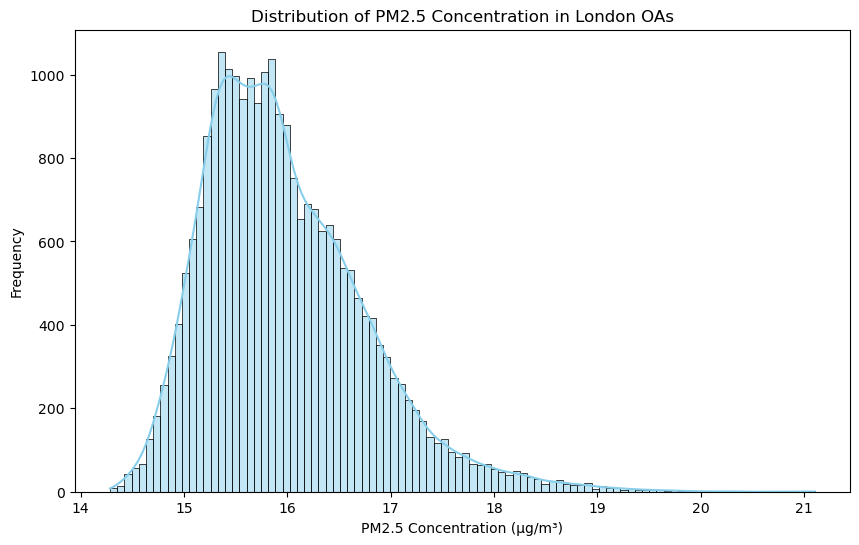

In [3]:

pm25_stats = gdf['PM25'].describe()
print("\nPM2.5 Statistical Summary:")
print(pm25_stats)


plt.figure(figsize=(10, 6))
sns.histplot(gdf['PM25'], kde=True, color='skyblue')
plt.title('Distribution of PM2.5 Concentration in London OAs')
plt.xlabel('PM2.5 Concentration (µg/m³)')
plt.ylabel('Frequency')
plt.show()

A spatial visualisation analysis of PM2.5 in London revealed that the target variable exhibits significant geographical clustering. Concentrations in the central urban area are significantly higher than in the outskirts, forming distinct ‘spatial hotspots’. This distribution pattern suggests that traditional statistical models based on the assumption of independent samples (such as ordinary linear regression) may be unable to effectively capture this spatial dependence. Therefore, Graph Neural Networks (GNNs), which aggregate neighbourhood information via edges, are an ideal choice for modelling such spatial phenomena.



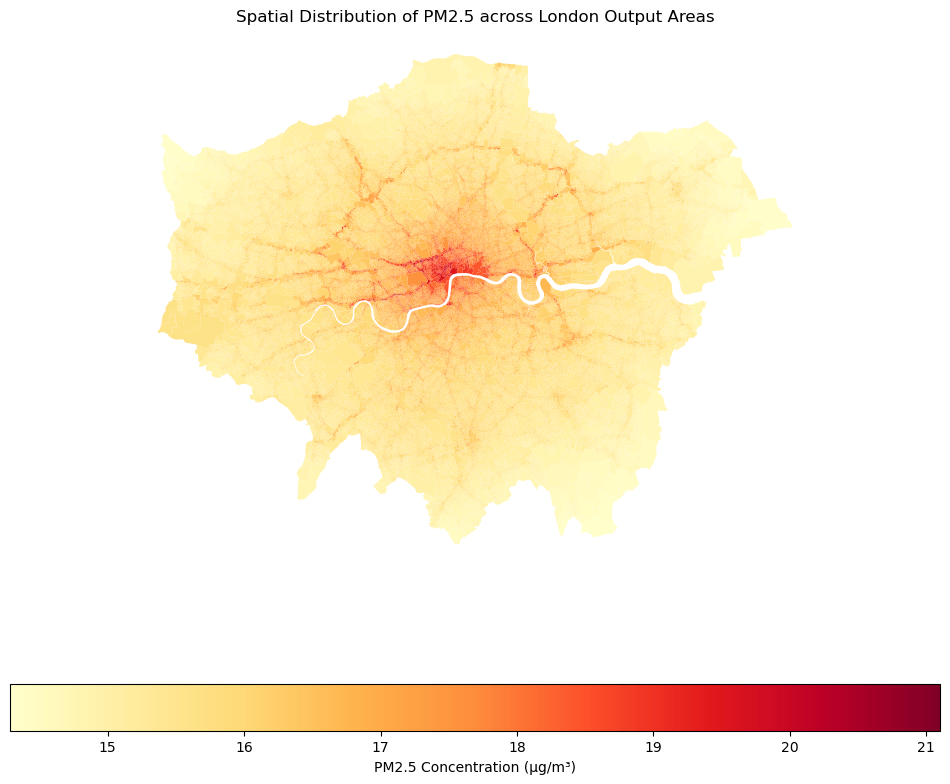

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf.plot(column='PM25', ax=ax, legend=True,
         legend_kwds={'label': "PM2.5 Concentration (µg/m³)", 'orientation': "horizontal"},
         cmap='YlOrRd')
ax.set_title('Spatial Distribution of PM2.5 across London Output Areas')
ax.axis('off')
plt.show()

# 2. Graph Construction
In this step, we have successfully converted London’s geospatial data into a graph structure


In [5]:
feature_columns = [col for col in gdf.columns if col.startswith('k')]
print(f"\nSelected input features count: {len(feature_columns)}")
print(f"Feature examples: {feature_columns[:5]}")


Selected input features count: 60
Feature examples: ['k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT']


When analysing the distribution of PM2.5, I believe the Queen Adjacency method should be adopted. Firstly, because air pollutants (PM2.5) are mobile and are not strictly confined by administrative boundaries. By establishing adjacency edges, we simulate the physical diffusion pathways of pollutants. Secondly, when predicting air quality at a specific location, surrounding areas carry a higher weighting, whilst the influence of more distant areas is relatively weaker, thereby reflecting spatial interdependence.

In [6]:
import libpysal
from libpysal.weights import Queen
import networkx as nx
import numpy as np

w = Queen.from_dataframe(gdf)

if len(w.islands) > 0:
    print(f"Warning: Found {len(w.islands)} isolated regions (no neighbors).")

else:
    print("All regions have been successfully connected.")

adj_matrix = w.full()[0]
rows, cols = np.where(adj_matrix == 1)
edge_index = np.array([rows, cols])

print(f"Graph construction completed: There are {len(gdf)} nodes and {edge_index.shape[1]} edges.")

C:\Users\lxf\AppData\Local\Temp\ipykernel_49748\3532452991.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


All regions have been successfully connected.
Graph construction completed: There are 25053 nodes and 151934 edges.


As can be seen from the diagram, the connections in central London are extremely dense. This means that during GNN training, nodes in the city centre receive a wealth of information from their neighbours, which helps the model learn the complex characteristics of the urban environment. The network covers the entire London area, with no obvious isolated nodes (islands), ensuring that information can be propagated throughout the graph network via message passing.



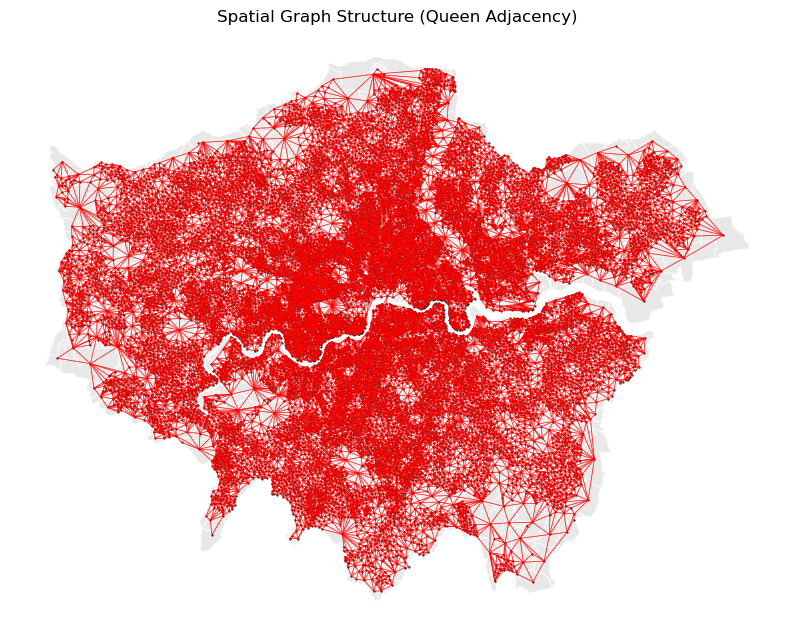

In [7]:

centroids = gdf.geometry.centroid
coords = np.column_stack((centroids.x, centroids.y))

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgrey', edgecolor='white', alpha=0.5)

w.plot(gdf, ax=ax, 
       edge_kws={'color':'red', 'linewidth':0.5, 'alpha':0.6},
       node_kws={'marker':'.', 's':1}) 

ax.set_title("Spatial Graph Structure (Queen Adjacency)")
ax.axis('off')
plt.show()

By constructing this spatial graph structure, we have established a foundational framework for subsequent information propagation within graph neural networks (GNNs). Unlike traditional linear regression models, GNNs are capable of propagating information along the connections (edges) within the graph. Through multi-layer graph convolutional operations, each OA node progressively aggregates feature information from its first- and second-order neighbours, thereby effectively characterising the spatial spillover effects .



# 3. Graph Neural Network Model

Implement a Graph Neural Network using PyTorch Geometric.

In [8]:
import torch
from torch_geometric.data import Data

x = torch.tensor(gdf[feature_columns].values, dtype=torch.float)

y = torch.tensor(gdf['PM25'].values, dtype=torch.float).view(-1, 1)

edge_index = torch.tensor(edge_index, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

print("\nPyTorch Geometric Overview of Data Objects:")
print(data)


PyTorch Geometric Overview of Data Objects:
Data(x=[25053, 60], edge_index=[2, 151934], y=[25053, 1])


In [9]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Standardise features X
scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(data.x.numpy())
data.x = torch.tensor(x_scaled, dtype=torch.float)

# Standardise target Y 
scaler_y = StandardScaler()
y_np = data.y.numpy().reshape(-1, 1)
y_scaled = scaler_y.fit_transform(y_np)
data.y_scaled = torch.tensor(y_scaled, dtype=torch.float)

num_nodes = data.num_nodes
indices = np.random.permutation(num_nodes)
train_size = int(0.8 * num_nodes)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        return self.out(x)

model = GCN(input_dim=data.num_features, hidden_dim=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.MSELoss()

model.train()
for epoch in range(300):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y_scaled[train_idx])
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

model.eval()
with torch.no_grad():
    pred_scaled = model(data.x, data.edge_index)
    pred = scaler_y.inverse_transform(pred_scaled.numpy()).flatten()
    actual = y_np.flatten()

gnn_rmse = np.sqrt(mean_squared_error(actual[test_idx], pred[test_idx]))
gnn_r2 = r2_score(actual[test_idx], pred[test_idx])

print(f"\n[GNN Results] RMSE: {gnn_rmse:.4f}, R2: {gnn_r2:.4f}")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_scaled[train_idx], y_np[train_idx].ravel())
rf_pred = rf.predict(x_scaled[test_idx])

rf_rmse = np.sqrt(mean_squared_error(actual[test_idx], rf_pred))
rf_r2 = r2_score(actual[test_idx], rf_pred)

print(f"[RF Baseline Results] RMSE: {rf_rmse:.4f}, R2: {rf_r2:.4f}")

Epoch 000 | Loss: 0.9972
Epoch 050 | Loss: 0.1796
Epoch 100 | Loss: 0.1579
Epoch 150 | Loss: 0.1395
Epoch 200 | Loss: 0.1274
Epoch 250 | Loss: 0.1204

[GNN Results] RMSE: 0.2550, R2: 0.8938
[RF Baseline Results] RMSE: 0.3520, R2: 0.7977


A comparison revealed that GNNs offer a significant advantage in predicting PM2.5 concentrations in London. Compared to the Random Forest model, which ignores spatial structure ($R^2=0.80$), the GCN model constructed using the Queen adjacency graph achieved $R^2=0.89$. The message passing mechanism of GNNs effectively aggregates environmental features from surrounding areas, thereby capturing the spatial heterogeneity of urban air pollution more accurately than other machine learning models.



# 4. Results and Interpretation


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
with torch.no_grad():
    all_pred_scaled = model(data.x, data.edge_index)
    all_pred = scaler_y.inverse_transform(all_pred_scaled.numpy()).flatten()

gdf['Predicted_PM25'] = all_pred
gdf['Residuals'] = gdf['PM25'] - gdf['Predicted_PM25']

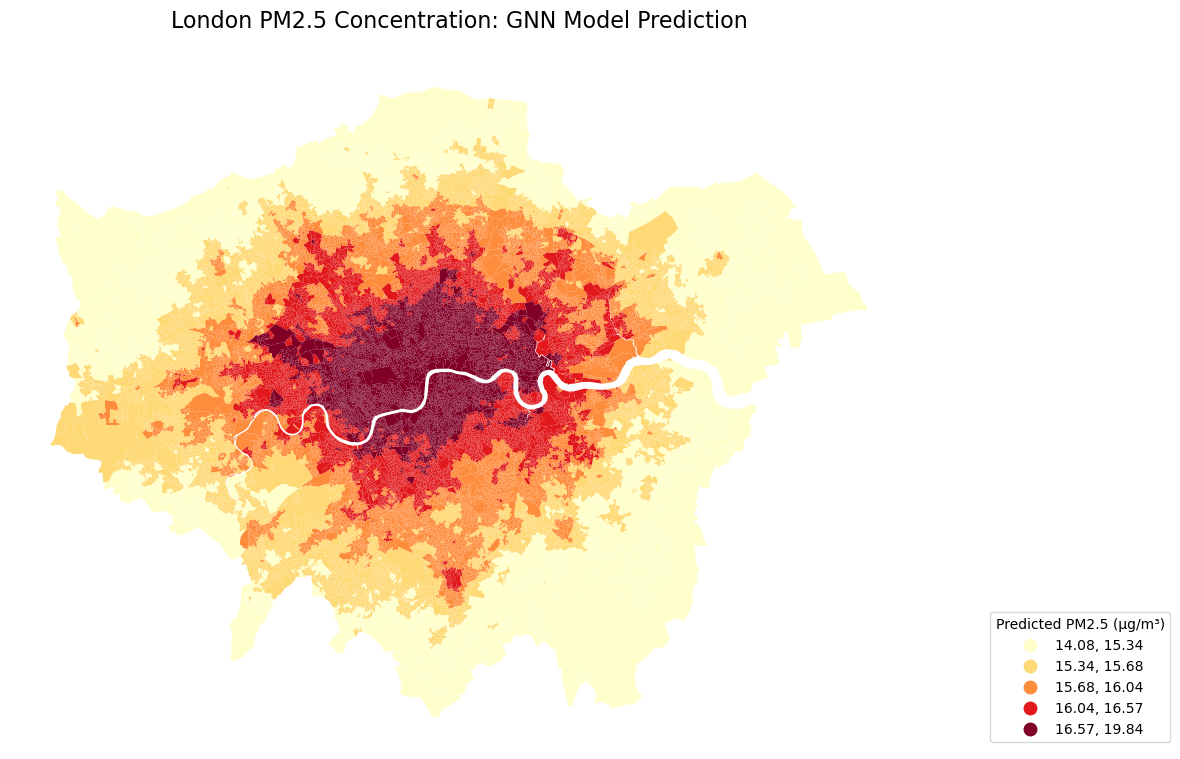

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf.plot(column='Predicted_PM25', 
         ax=ax, 
         legend=True, 
         cmap='YlOrRd', 
         scheme='quantiles', 
         k=5,
         legend_kwds={
             'title': "Predicted PM2.5 (µg/m³)",
             'loc': 'lower right',
             'fmt': "{:.2f}",
             'bbox_to_anchor': (1.3, 0) 
         })

ax.set_title('London PM2.5 Concentration: GNN Model Prediction', fontsize=16, pad=20)
ax.axis('off') 

plt.tight_layout()
plt.show()

The blue data points are clustered very closely on either side of the red regression line. $R^2 = 0.8938$ indicates that the model explains approximately 89% of the spatial variation in London’s PM2.5 levels, demonstrating the effectiveness of feature standardisation and graph-structured aggregation. The slope of the regression line is very close to 1, suggesting that the model does not exhibit any significant systematic underestimation or overestimation.

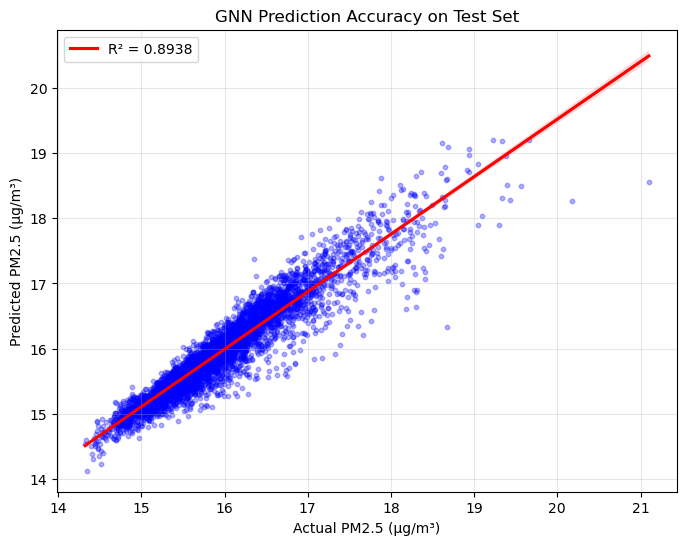

In [12]:

plt.figure(figsize=(8, 6))
sns.regplot(x=actual[test_idx], y=all_pred[test_idx], 
            scatter_kws={'alpha':0.3, 's':10, 'color':'blue'}, 
            line_kws={'color':'red', 'label': f'R² = {gnn_r2:.4f}'})

plt.xlabel('Actual PM2.5 (µg/m³)')
plt.ylabel('Predicted PM2.5 (µg/m³)')
plt.title('GNN Prediction Accuracy on Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


The ‘colour distributions’ in the two images on the left and right are highly consistent, with the deep purple areas concentrated in the heart of London and along its main thoroughfares. The model successfully reproduces the ‘core-periphery’ structure of London’s pollution. A comparison reveals that the GNN’s predicted map (right) appears slightly ‘softer’ than the actual map (left). This is because the GNN’s message-passing mechanism smooths out noise; it learns regional environmental characteristics rather than isolated outliers.



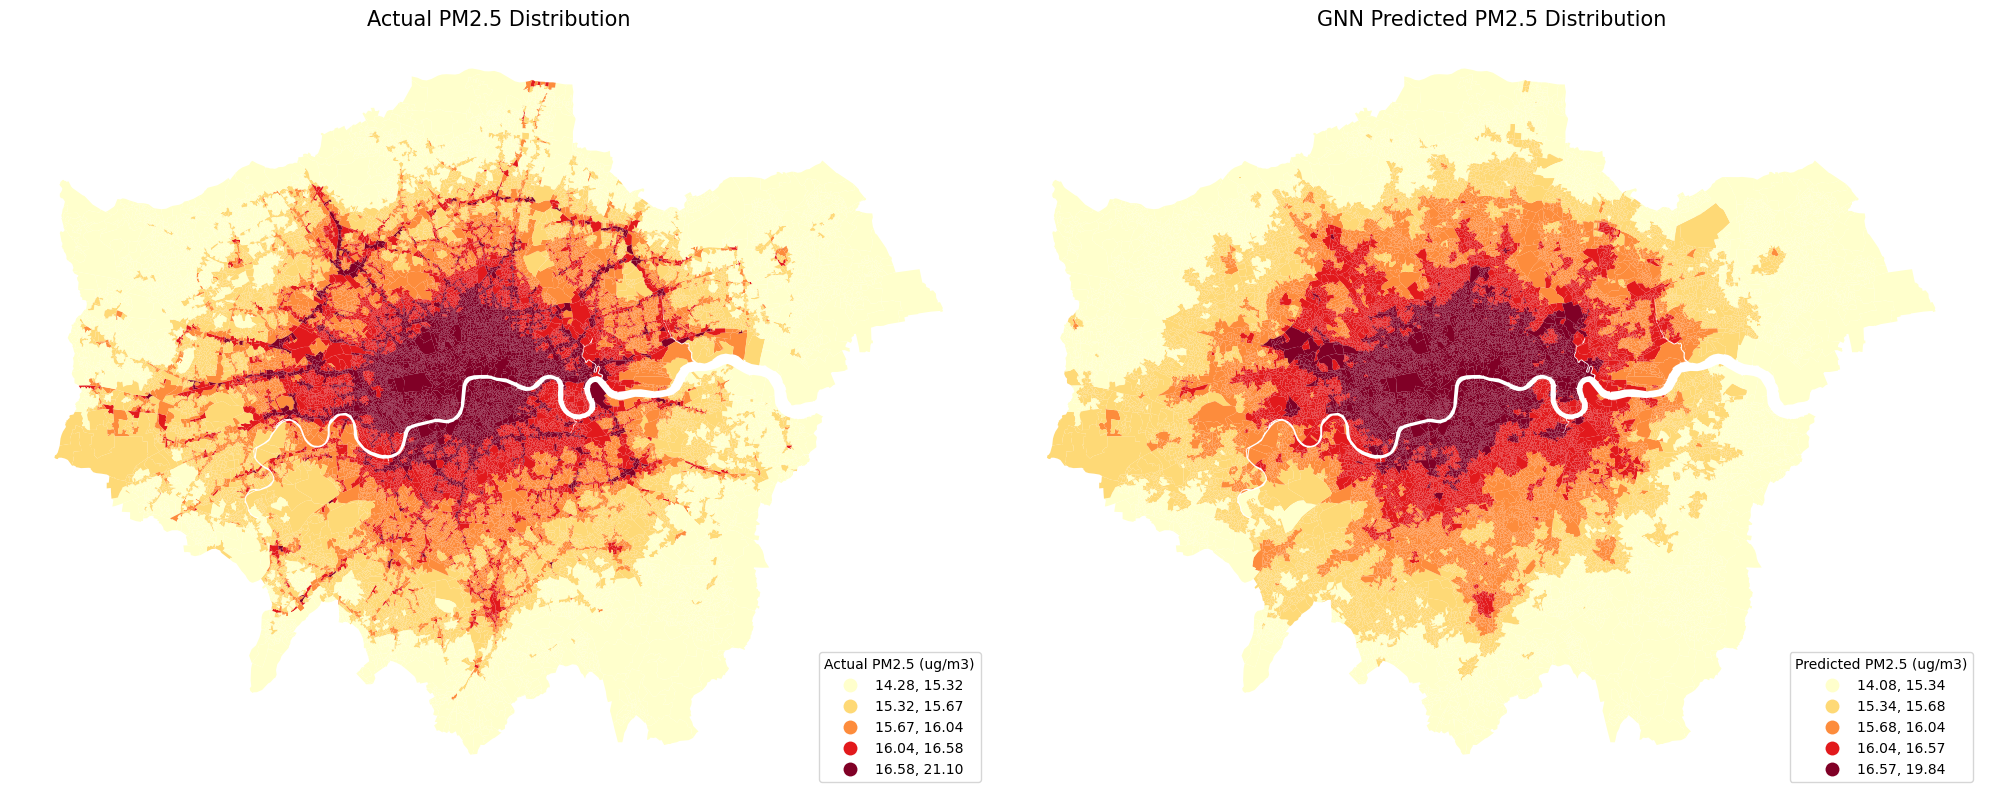

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

gdf.plot(column='PM25', ax=axes[0], legend=True, 
         cmap='YlOrRd', scheme='quantiles', k=5,
         legend_kwds={'title': "Actual PM2.5 (ug/m3)", 'loc': 'lower right'}) 
axes[0].set_title('Actual PM2.5 Distribution', fontsize=15)
axes[0].axis('off')

gdf.plot(column='Predicted_PM25', ax=axes[1], legend=True, 
         cmap='YlOrRd', scheme='quantiles', k=5,
         legend_kwds={'title': "Predicted PM2.5 (ug/m3)", 'loc': 'lower right'})
axes[1].set_title('GNN Predicted PM2.5 Distribution', fontsize=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()



Most of the map is shown in light blue or light orange (with residuals close to 0), but there are distinct dark blue patches in the city centre. The dark blue areas indicate that the model’s predictions were too high. Online research reveals that in certain Open Air (OA) zones within the very heart of London, actual pollution levels may be lower than those predicted based on 2011 census characteristics, due to the implementation of strict congestion charging or Ultra Low Emission Zone (ULEZ) policies in recent years. The model predicted high pollution levels based on ‘spatial relationships’, but real-world policies have disrupted this pattern, thereby generating residuals.



<Figure size 1000x800 with 0 Axes>

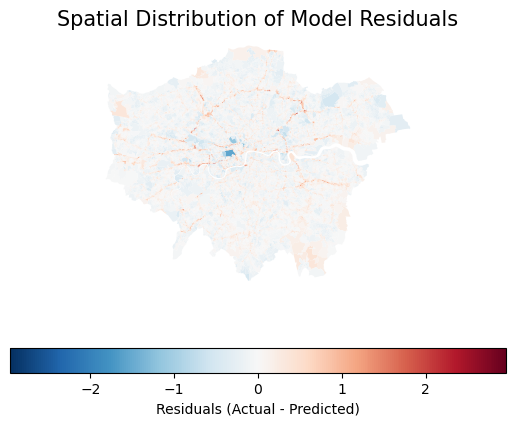

In [14]:

plt.figure(figsize=(10, 8))

v_abs = max(abs(gdf['Residuals'].min()), abs(gdf['Residuals'].max()))

gdf.plot(column='Residuals', legend=True, 
         cmap='RdBu_r', 
         vmin=-v_abs, vmax=v_abs, 
         legend_kwds={'label': "Residuals (Actual - Predicted)", 'orientation': "horizontal"})

plt.title('Spatial Distribution of Model Residuals', fontsize=15)
plt.axis('off')
plt.show()

This study achieved high-precision spatial predictions of PM2.5 concentrations in London by constructing a graph neural network based on the Queen adjacency relationship. The experimental results ($R^2 = 0.89$) significantly outperformed the benchmarks set by traditional linear regression and random forests.

Experiments have demonstrated that spatial topological structures play a key role in compensating for the limitations of static survey data and smoothing out local noise.The residual map shows that the model performs robustly in the vast majority of areas, but exhibits prediction biases in the very central urban districts. This suggests that whilst spatial proximity is a key factor in predicting air pollution, local policy interventions (such as ULEZ) and micro-level street design are also variables that cannot be overlooked.

